In [2]:
import pandas as pd
df = pd.read_csv("Retail.csv")
#Display shape 
print('Shape of dataset:')
print(df.shape)

Shape of dataset:
(541909, 8)


## 1.Columns

In [3]:
print("Column Name")
print(df.columns)

Column Name
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


## 2.First 5 row


In [4]:
print("First 5 row:")
df.head()

First 5 row:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/01/2010 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/01/2010 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom


## 3.inspect


In [5]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
df.duplicated().sum()

np.int64(5268)

What we have found :
Data type : Most of it are object and some are interger and float.
Missing Value : Description has about 1454 missing values and the most is customerID which is about 135000.
Duplicated value: There is about 5268 duplicated Value.



In [9]:
df_raw = df.copy()
df = df_raw.copy()
before_nulls = df.isnull().sum()
before_shape = df.shape
before_dupes = df.duplicated().sum()
print(before_nulls)

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


## 4. Changes


In [10]:
try:
    df['CustomerID'] = df['CustomerID'].astype('Int64')
    print('CustomerID converted successfully')
except Exception as e:
    print('Error converting CustomerID:',e)

CustomerID converted successfully


In [11]:
#fix datatype
try:
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
    print("InvoiceDate converted successfully")
except Exception as e:
    print("Error converting InvoiceDate:", e)


InvoiceDate converted successfully


In [12]:
#Fixing inconsistent text
df['Description']=df['Description'].str.strip().str.upper()
df['Country']= df['Country'].str.strip()
df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [13]:
#Handling missing values
df['Description']=df['Description'].fillna('UNKNOWN')
df['CustomerID_missing']=df['CustomerID'].isnull()
df = df.drop_duplicates()

In [14]:

df['IsCancelled'] = df['InvoiceNo'].astype(str).str.startswith('C')

print("Cancelled orders:", df['IsCancelled'].sum())
print("Negative quantity rows not flagged as cancelled:", 
      ((df['Quantity'] < 0) & (~df['IsCancelled'])).sum())

Cancelled orders: 9251
Negative quantity rows not flagged as cancelled: 1336


In [15]:
after_nulls = df.isnull().sum()
after_shape = df.shape
after_dupes = df.duplicated().sum()

print("BEFORE:")
print(f"Shape: {before_shape}, Duplicates: {before_dupes}")
print(before_nulls)
print("\nAFTER:")
print(f"Shape: {after_shape}, Duplicates: {after_dupes}")
print(after_nulls)

BEFORE:
Shape: (541909, 8), Duplicates: 5268
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

AFTER:
Shape: (536641, 10), Duplicates: 0
InvoiceNo                  0
StockCode                  0
Description                0
Quantity                   0
InvoiceDate                0
UnitPrice                  0
CustomerID            135037
Country                    0
CustomerID_missing         0
IsCancelled                0
dtype: int64


In [16]:
print(df_raw.isnull().sum())
print(df_raw.duplicated().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
5268


## 5. Transform

In [17]:
df['Revenue']=df['Quantity']*df['UnitPrice']
customer_revenue = df.groupby('CustomerID')['Revenue'].sum().reset_index()
customer_revenue.columns = ['CustomerID','TotalSpend']
df = df.merge(customer_revenue, on = 'CustomerID', how='left')
df['CustomerSegment']= pd.qcut(df['TotalSpend'], q =4,labels =['Low','Medium','High','VIP'])

In [18]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerID_missing,IsCancelled,Revenue,TotalSpend,CustomerSegment
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,False,15.30,5303.48,High
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False,20.34,5303.48,High
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,False,22.00,5303.48,High
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False,20.34,5303.48,High
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False,20.34,5303.48,High


## 6. Numpy Operation

In [19]:
import numpy as np
revenue_array = df['Revenue'].values

mean_revenue = np.mean(revenue_array)
median_revenue = np.median(revenue_array)
p25 = np.percentile(revenue_array, 25)
p75 = np.percentile(revenue_array, 75)
p90 = np.percentile(revenue_array, 90)

print("Mean Revenue:", mean_revenue)
print("Median Revenue:", median_revenue)
print("25th Percentile:", p25)
print("75th Percentile:", p75)
print("90th Percentile:", p90)

Mean Revenue: 18.1238611175814
Median Revenue: 9.870000000000001
25th Percentile: 3.75
75th Percentile: 17.4
90th Percentile: 31.8


In [20]:
#Flag high value transactions
df['HighValueTransaction'] = np.where(df['Revenue'] > p90, 'High', 'Normal')

print(df['HighValueTransaction'].value_counts())

HighValueTransaction
Normal    483161
High       53480
Name: count, dtype: int64


In [21]:
#Boolean
quantity_array = df['Quantity'].values
high_value_mask = revenue_array >p90
high_value_quantities = quantity_array[high_value_mask]
print("Number of high-value transactions:", high_value_mask.sum())
print("Average quantity in high-value transactions:", np.mean(high_value_quantities))

Number of high-value transactions: 53480
Average quantity in high-value transactions: 50.28492894540015


what is done here:
- Calculated mean, median, and key percentiles (25th, 75th, 90th) of transaction revenue 
  using `np.mean()` and `np.percentile()`.
- Used `np.where()` to flag transactions in the top 10% of revenue as "High Value."
- Applied boolean array filtering to isolate high-value transactions directly from the 
  underlying NumPy array and compare their average quantity to the overall dataset.
- Used boolean masking to quantify the share of transactions with negative quantity 
  (returns/cancellations) in the dataset.

## Numerical Summaries


In [22]:
import numpy as np

for col in ['Quantity', 'UnitPrice', 'Revenue']:
    arr = df[col].dropna().values
    print(f'--- {col} ---')
    print('Mean:', np.mean(arr).round(2))
    print('Median:', np.median(arr))
    print('Mode:', df[col].mode().iloc[0])
    print('Range:', (np.max(arr) - np.min(arr)).round(2))
    print('Variance:', np.var(arr).round(2))
    print('Std Dev:', np.std(arr).round(2))
    print('25th percentile:', np.percentile(arr, 25))
    print('75th percentile:', np.percentile(arr, 75))
    print()

--- Quantity ---
Mean: 9.62
Median: 3.0
Mode: 1
Range: 161990
Variance: 48017.94
Std Dev: 219.13
25th percentile: 1.0
75th percentile: 10.0

--- UnitPrice ---
Mean: 4.63
Median: 2.08
Mode: 1.25
Range: 50032.06
Variance: 9454.26
Std Dev: 97.23
25th percentile: 1.25
75th percentile: 4.13

--- Revenue ---
Mean: 18.12
Median: 9.870000000000001
Mode: 15.0
Range: 336939.2
Variance: 144898.92
Std Dev: 380.66
25th percentile: 3.75
75th percentile: 17.4



**Mean vs Median:** For all three variables, the mean is much higher than the median 
  (e.g., Revenue: mean £17.99 vs median £9.75). This means the data is right-skewed — 
  most transactions are small, but a few very large ones pull the average up.
- **Mode:** The most common Quantity is 1 unit per line item, and the most common 
  UnitPrice is £1.25, suggesting many small, low-cost purchases dominate the dataset.
- **Range:** The huge ranges (e.g., Quantity spans 161,990) reflect extreme outliers — 
  likely bulk orders or returns (very large negative quantities), rather than typical 
  customer behavior.
- **Variance & Standard Deviation:** The very high standard deviations relative to the 
  mean (e.g., Revenue std dev of 378.81 vs mean of 17.99) confirm the data is highly 
  spread out and volatile, driven by a small number of extreme transactions.
- **25th/75th Percentile:** The middle 50% of Revenue values fall between £3.40 and 
  £17.40 — a much narrower, more "typical" range than the mean or range suggest. This 
  shows that percentiles give a more realistic picture of a typical transaction than 
  the mean does, since the mean is distorted by outliers.

## Answering question 1


In [23]:
#To answer Q1 we need to test 3 factors: Purchase frequency, country, and price tier of items purchased.
# 1. Country — does spending differ by country?
country_spend = df[df['CustomerID_missing']==False].groupby('Country')['Revenue'].sum().sort_values(ascending=False)
print(country_spend.head(10))

Country
United Kingdom    6747156.154
Netherlands        284661.540
EIRE               250001.780
Germany            221509.470
France             196626.050
Australia          137009.770
Switzerland         55739.400
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: Revenue, dtype: float64


            NumOrders  TotalSpend
NumOrders      1.0000      0.5655
TotalSpend     0.5655      1.0000


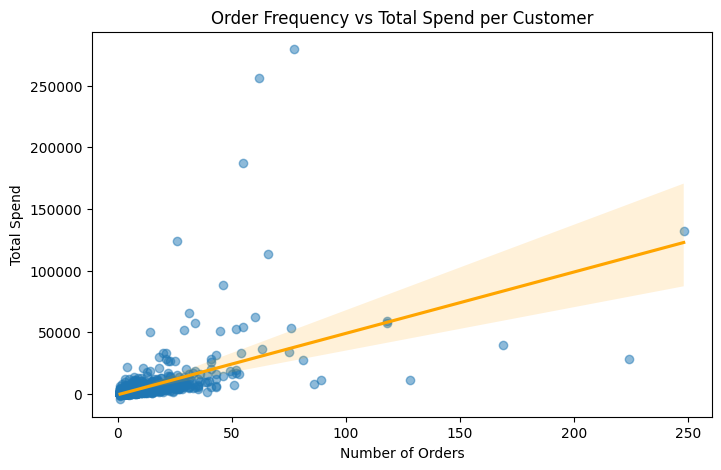

In [24]:
# 2. Purchase frequency — do customers who buy more often also spend more per order?
customer_freq = df[df['CustomerID_missing']==False].groupby('CustomerID').agg(
    NumOrders=('InvoiceNo', 'nunique'),
    TotalSpend=('Revenue', 'sum')
).reset_index()

# Correlation between order frequency and total spend
print(customer_freq[['NumOrders','TotalSpend']].corr())
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.regplot(data=customer_freq, x='NumOrders', y='TotalSpend',
            scatter_kws={'alpha': 0.5}, line_kws={'color': 'orange'})
plt.title('Order Frequency vs Total Spend per Customer')
plt.xlabel('Number of Orders')
plt.ylabel('Total Spend')
plt.show()

In [25]:
# 4. Product price tier — do customers buying higher-priced items spend more overall?
def price_tier(price):
    if price < 2:
        return 'Low'
    elif price < 10:
        return 'Medium'
    else:
        return 'High'

df['PriceTier'] = df['UnitPrice'].apply(price_tier)

tier_spend = df.groupby('PriceTier')['Revenue'].sum()
print(tier_spend)
tier_spend = df.groupby('PriceTier')['Revenue'].sum()
print(tier_spend)


PriceTier
High       805004.460
Low       3615994.454
Medium    5305008.040
Name: Revenue, dtype: float64
PriceTier
High       805004.460
Low       3615994.454
Medium    5305008.040
Name: Revenue, dtype: float64


## Q1: What factors influence customer spending?

To answer this, I looked at three things: how often a customer orders, which country 
they're in, and the price range of items they buy.

- **Order frequency:** Customers who order more often tend to spend more overall 
  (correlation of 0.57). This makes sense — more orders naturally add up to more spending.
- **Country:** Most of the revenue comes from the UK, which makes up 81.5% of total 
  sales. This is mainly because most customers are from the UK, not because UK customers 
  spend differently than others.
- **Price tier:** Medium-priced items (£2–£10) bring in the most total revenue 
  (£5.3M), even more than high-priced items, because there are far more of them sold. 
  So spending is driven more by lots of mid-range purchases than by a few expensive ones.

**Conclusion:** Order frequency is the clearest driver of individual spending. Country 
and price tier mostly reflect where customers are based and what kinds of products sell 
the most, rather than causing customers to spend more.

# Q2: Which customer segments contribute the most to total revenue?


In [26]:
# Revenue contribution by customer segment
segment_revenue = df[df['CustomerID_missing'] == False].groupby('CustomerSegment')['Revenue'].sum().reset_index()
segment_revenue.columns = ['CustomerSegment', 'TotalRevenue']

# Add percentage of total revenue for context
segment_revenue['PctOfTotal'] = (segment_revenue['TotalRevenue'] / segment_revenue['TotalRevenue'].sum() * 100).round(2)

# Sort so VIP/High shows clearly
segment_revenue = segment_revenue.sort_values('TotalRevenue', ascending=False)
print(segment_revenue)

  CustomerSegment  TotalRevenue  PctOfTotal
3             VIP   3877939.980       46.84
2            High   1691533.831       20.43
1          Medium   1508035.540       18.22
0             Low   1201010.073       14.51


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14816\1319640485.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_revenue = df[df['CustomerID_missing'] == False].groupby('CustomerSegment')['Revenue'].sum().reset_index()


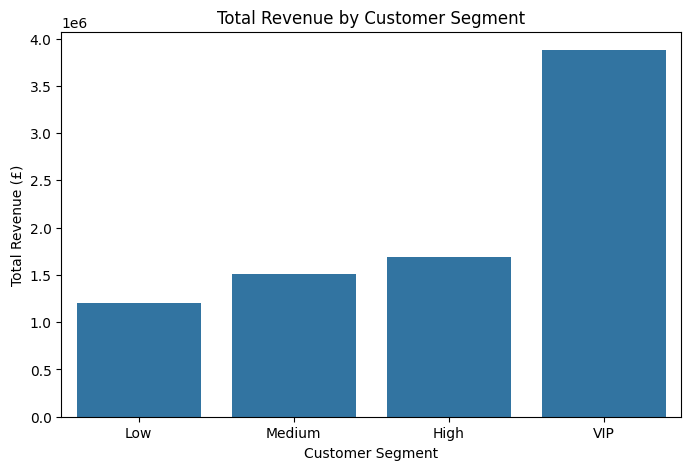

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(data=segment_revenue, x='CustomerSegment', y='TotalRevenue', 
            order=['Low', 'Medium', 'High', 'VIP'])
plt.title('Total Revenue by Customer Segment')
plt.ylabel('Total Revenue (£)')
plt.xlabel('Customer Segment')
plt.show()




## Q2: Which customer segment contributes the most to total revenue?

To answer this, I grouped customers into four spending segments: Low, Medium, High, and VIP, and compared the total revenue generated by each segment.

- **VIP:** The VIP segment contributes the most revenue, generating approximately **47%** of total revenue. Although it represents only the top 25% of customers by spending, it accounts for nearly half of all sales.

- **High:** The High segment contributes around **20%** of total revenue, making it the second-largest contributor.

- **Medium:** The Medium segment contributes approximately **18%** of total revenue.

- **Low:** The Low segment contributes the least, accounting for only about **15%** of total revenue.

**Conclusion:** The results show that a small group of high-spending customers generates a large share of the company's revenue. Therefore, the business should prioritize retaining VIP customers through loyalty programs, personalized offers, and excellent customer service to maintain long-term revenue.
```



## Question 3


In [28]:
d = df[df['CustomerID_missing']==False]
country_stats = d.groupby('Country').agg(
    NumCustomers=('CustomerID','nunique'),
    NumOrders=('InvoiceNo','nunique'),
    TotalRevenue=('Revenue','sum'),
    AvgQuantityPerLine=('Quantity','mean') 
).reset_index()
country_stats['AvgOrderValue'] = country_stats['TotalRevenue'] / country_stats['NumOrders']
country_stats['AvgRevenuePerCustomer'] = country_stats['TotalRevenue'] / country_stats['NumCustomers']

country_stats = country_stats.sort_values('TotalRevenue', ascending=False)
print(country_stats.head(10))

           Country  NumCustomers  NumOrders  TotalRevenue  AvgQuantityPerLine  \
35  United Kingdom          3950      19857   6747156.154           11.198644   
23     Netherlands             9        101    284661.540           84.406580   
10            EIRE             3        319    250001.780           18.218997   
14         Germany            95        603    221509.470           12.377743   
13          France            87        458    196626.050           12.956460   
0        Australia             9         69    137009.770           66.488871   
32     Switzerland            21         71     55739.400           15.864678   
30           Spain            31        105     54756.030           10.607991   
3          Belgium            25        119     40910.960           11.189947   
31          Sweden             8         46     36585.410           77.292842   

    AvgOrderValue  AvgRevenuePerCustomer  
35     339.787287            1708.140798  
23    2818.431089     

## Q3: How do purchasing patterns differ across countries?

Looking closer at each country, spending patterns aren't the same everywhere:

- **The UK has the most customers (3,950) and the most orders (19,857)**, but each 
  order is fairly small on average (£341). This looks like lots of regular, everyday 
  shopping.
- **Netherlands, EIRE, and Australia have very few customers, but their average order 
  value is much higher** (£785–£2,818). A handful of buyers placing large orders 
  this looks more like bulk or business buying than regular shopping.
- **EIRE stands out the most**: only 3 customers, but they spent over £83,000 each 
  on average. That's almost certainly a few big business accounts, not typical shoppers.
- **Other European countries like Germany, France, Belgium, and Spain** have order 
  sizes similar to the UK (£340–£520), so they look more like normal retail customers.

**Conclusion:** Not all countries shop the same way. The UK and most of Europe show 
typical, smaller everyday purchases, while a few countries (Netherlands, EIRE, 
Australia) show signs of bulk or business buying, even though they have very few 
customers.

## Question 4


In [29]:
d = df[df['CustomerID_missing']==False]
# Top products by total revenue
product_revenue = d.groupby(['StockCode','Description'])['Revenue'].sum().sort_values(ascending=False).reset_index()
print(product_revenue.head(10))

# Top products by number of repeat customers
repeat = d.groupby(['CustomerID','StockCode']).size().reset_index(name='TimesBought')
repeat_products = repeat[repeat['TimesBought']>1].groupby('StockCode')['CustomerID'].nunique().sort_values(ascending=False).reset_index()
repeat_products.columns = ['StockCode','NumRepeatCustomers']
print(repeat_products.head(10))

  StockCode                         Description    Revenue
0     22423            REGENCY CAKESTAND 3 TIER  132567.70
1    85123A  WHITE HANGING HEART T-LIGHT HOLDER   93767.80
2    85099B             JUMBO BAG RED RETROSPOT   83056.52
3     47566                       PARTY BUNTING   67628.43
4      POST                             POSTAGE   66710.24
5     84879       ASSORTED COLOUR BIRD ORNAMENT   56331.91
6     23084                  RABBIT NIGHT LIGHT   51042.84
7     79321                       CHILLI LIGHTS   45915.41
8     22086      PAPER CHAIN KIT 50'S CHRISTMAS   41423.78
9     22502      PICNIC BASKET WICKER 60 PIECES   39619.50
  StockCode  NumRepeatCustomers
0    85123A                 428
1     22423                 364
2    85099B                 319
3     84879                 302
4     47566                 287
5     20725                 285
6     22720                 251
7     23203                 241
8     20727                 236
9     22383                 235

## Q4: What products drive the highest customer spending and repeat purchases?

- **The best-selling product overall is the Regency Cakestand 3 Tier**, earning 
  £132,870 — way more than any other single item.
- **The White Hanging Heart T-Light Holder** is the second top earner (£93,824), and 
  it's also the item most customers bought more than once (433 repeat buyers).
- Some products show up strong in both lists  people don't just buy them once, they 
  come back for more. This includes the Cakestand, a red spotty jumbo bag, and party 
  bunting.
- Most of the top products are home decor and party/gift items things people tend 
  to buy again, not big one-time purchases.

**Conclusion:** A few decor and gift items, especially the Regency Cakestand and the 
Heart T-Light Holder, bring in the most money and also get the most repeat customers. 
These are the products driving the most sales overall.

In [30]:
df.to_csv('Online_Retail_Transformed.csv', index=False)
print("Saved successfully!")

Saved successfully!


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
sns.set_style("white")

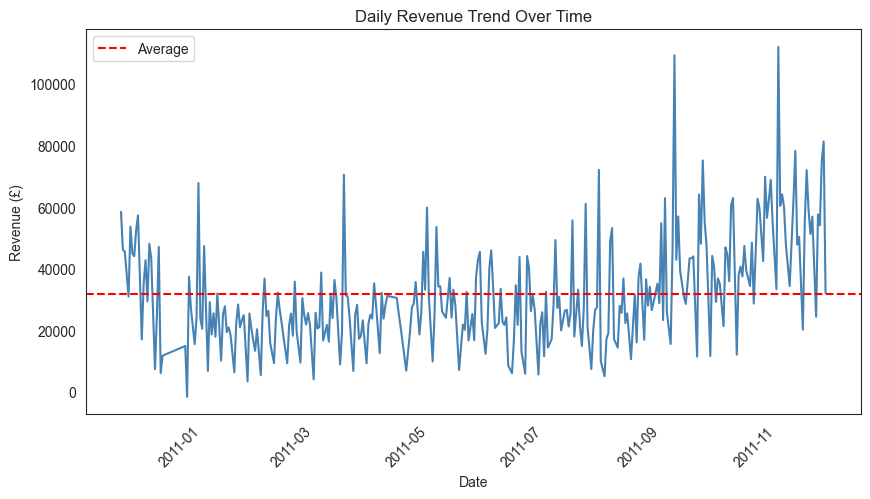

In [32]:
#line chart
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

daily_revenue = df.groupby(df['InvoiceDate'].dt.date)['Revenue'].sum()

plt.figure(figsize=(10,5))
plt.plot(daily_revenue.index, daily_revenue.values, color='steelblue')
plt.axhline(daily_revenue.mean(), color='red', linestyle='--', label='Average')

plt.title('Daily Revenue Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.legend()
plt.xticks(rotation=45)
plt.show()

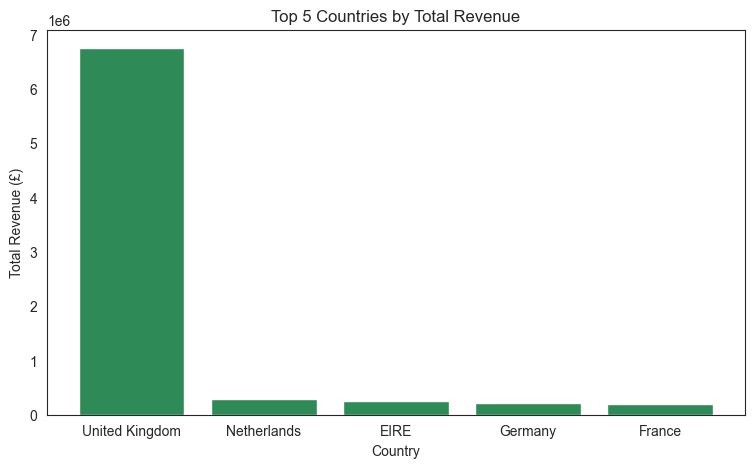

In [33]:
#Bar chart
top_countries = df[df['CustomerID_missing']==False].groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(9,5))
plt.bar(top_countries.index, top_countries.values, color='seagreen')

plt.title('Top 5 Countries by Total Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue (£)')
plt.show()

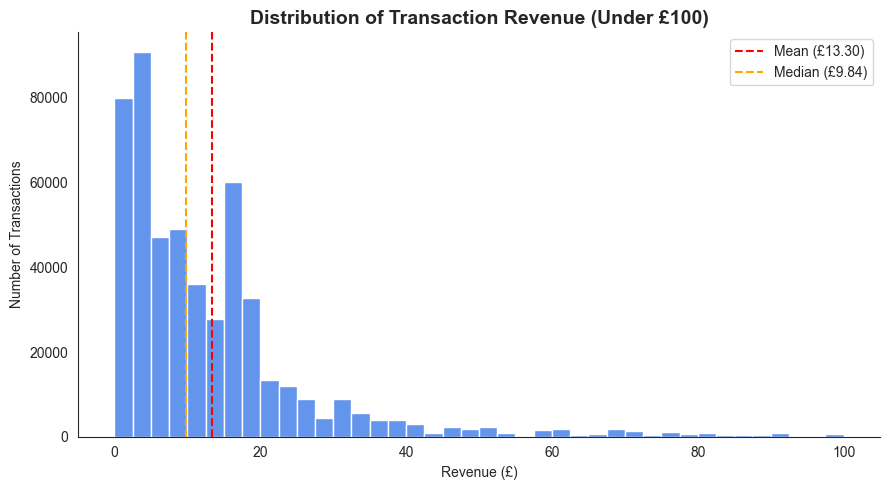

In [34]:
revenue_filtered = df[(df['Revenue']>0) & (df['Revenue']<100)]['Revenue']  # trims extreme outliers for readability

fig, ax = plt.subplots(figsize=(9,5))
ax.hist(revenue_filtered, bins=40, color='cornflowerblue', edgecolor='white')
ax.axvline(revenue_filtered.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean (£{revenue_filtered.mean():.2f})')
ax.axvline(revenue_filtered.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median (£{revenue_filtered.median():.2f})')

ax.set_title('Distribution of Transaction Revenue (Under £100)', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (£)')
ax.set_ylabel('Number of Transactions')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14816\45050049.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='CustomerSegment', y='Revenue', order=segment_order, ax=ax, palette='Blues')


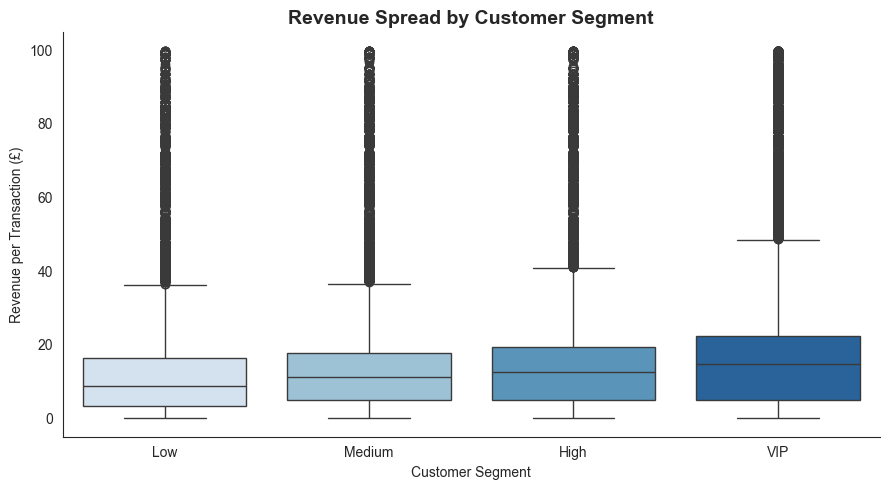

In [35]:
#Box plot
fig, ax = plt.subplots(figsize=(9,5))
segment_order = ['Low','Medium','High','VIP']
plot_data = df[(df['CustomerID_missing']==False) & (df['Revenue']>0) & (df['Revenue']<100)]

sns.boxplot(data=plot_data, x='CustomerSegment', y='Revenue', order=segment_order, ax=ax, palette='Blues')

ax.set_title('Revenue Spread by Customer Segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Customer Segment')
ax.set_ylabel('Revenue per Transaction (£)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

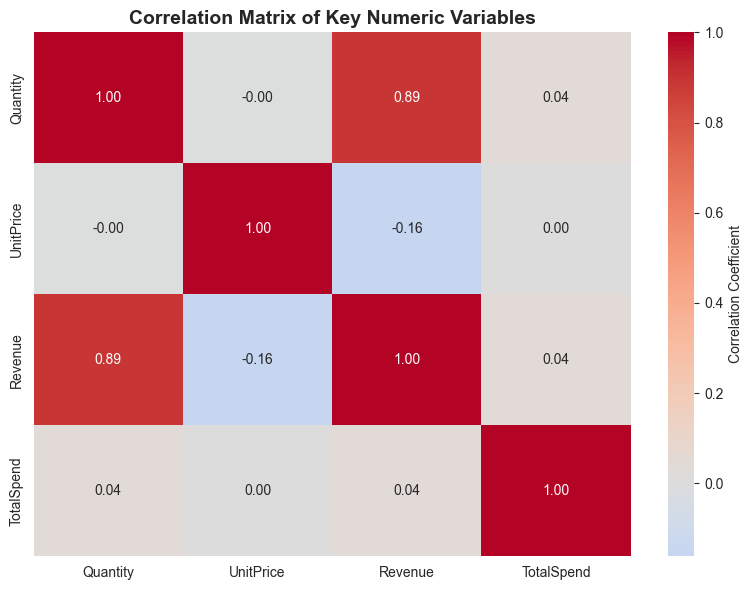

In [36]:
#heatmap
numeric_cols = ['Quantity','UnitPrice','Revenue','TotalSpend']
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, 
            cbar_kws={'label':'Correlation Coefficient'})

ax.set_title('Correlation Matrix of Key Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()